In [7]:
import kagglehub

kagglehub.login()

In [8]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('green-grid-forecasting-daily-household-energy-consumption')

print("Path to competition files:", path)

Path to competition files: /home/ttran/.cache/kagglehub/competitions/green-grid-forecasting-daily-household-energy-consumption


Cookie fetch from fc.yahoo.com failed (ConnectionError), continuing without it
[*********************100%***********************]  1 of 1 completed


                       Zero Mean - GARCH Model Results                        
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -1539.86
Distribution:                  Normal   AIC:                           3085.72
Method:            Maximum Likelihood   BIC:                           3100.46
                                        No. Observations:                 1005
Date:                Thu, Aug 27 2026   Df Residuals:                     1005
Time:                        15:09:30   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0545  2.209e-02      2.466  1.368e-02 [1.

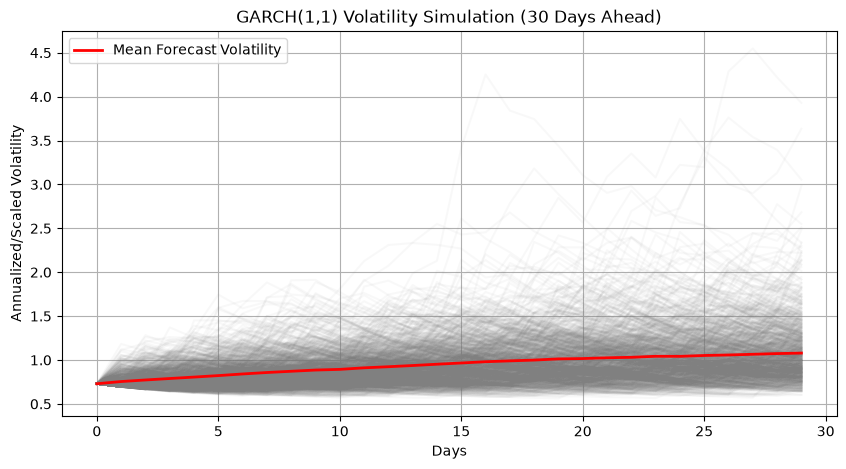

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt

# 1. Download historical stock data (e.g., S&P 500)
ticker = "^GSPC"
data = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# Calculate percentage log returns (GARCH models scale better with 100 * log returns)
data['Returns'] = 100 * np.log(data['Close'] / data['Close'].shift(1))
returns = data['Returns'].dropna()

# 2. Fit a GARCH(1,1) Model
# p=1 (GARCH lag), q=1 (ARCH lag)
model = arch_model(returns, vol='Garch', p=1, q=1, mean='Zero', dist='Normal')
fitted_model = model.fit(disp='off')

# Display estimated parameters (\omega, \alpha, \beta)
print(fitted_model.summary())

# 3. Simulate Future Volatility & Returns
horizon = 30       # Number of days to simulate ahead
num_sims = 1000    # Number of Monte Carlo simulation paths

# NOTE: `fitted_model.simulate(...)` does not exist on `ARCHModelResult`.
# The multi-path Monte Carlo forecast is done manually below using the fitted parameters.
np.random.seed(42)

# Manual Monte Carlo simulation using fitted parameters:
omega = fitted_model.params['omega']
alpha = fitted_model.params['alpha[1]']
beta = fitted_model.params['beta[1]']

simulated_vols = np.zeros((horizon, num_sims))

for sim in range(num_sims):
    last_var = fitted_model.conditional_volatility.iloc[-1]**2
    last_res = fitted_model.resid.iloc[-1]
    
    for t in range(horizon):
        # Calculate current conditional variance
        new_var = omega + alpha * (last_res**2) + beta * last_var
        new_vol = np.sqrt(new_var)
        
        # Generate random shock
        z = np.random.normal(0, 1)
        new_res = new_vol * z
        
        # Store volatility
        simulated_vols[t, sim] = new_vol
        
        # Update for next step
        last_var = new_var
        last_res = new_res

# 4. Plot Results
plt.figure(figsize=(10, 5))
plt.plot(simulated_vols, color='grey', alpha=0.05)
plt.plot(simulated_vols.mean(axis=1), color='red', linewidth=2, label='Mean Forecast Volatility')
plt.title(f'GARCH(1,1) Volatility Simulation ({horizon} Days Ahead)')
plt.xlabel('Days')
plt.ylabel('Annualized/Scaled Volatility')
plt.legend()
plt.grid(True)
plt.show()

Analytic (closed-form) forecast volatility:
1     0.729684
2     0.755961
3     0.780632
4     0.803864
5     0.825799
6     0.846555
7     0.866234
8     0.884924
9     0.902703
10    0.919639
11    0.935791
12    0.951213
13    0.965952
14    0.980053
15    0.993554
16    1.006491
17    1.018897
18    1.030800
19    1.042228
20    1.053207
21    1.063760
22    1.073908
23    1.083671
24    1.093068
25    1.102116
26    1.110832
27    1.119231
28    1.127326
29    1.135132
30    1.142661
dtype: float64

Monte Carlo mean volatility:
1     0.729684
2     0.754758
3     0.772629
4     0.789234
5     0.805528
6     0.822513
7     0.841045
8     0.857598
9     0.871740
10    0.885696
11    0.893267
12    0.910942
13    0.923532
14    0.937266
15    0.952059
16    0.966020
17    0.980469
18    0.990149
19    0.999284
20    1.012669
21    1.016530
22    1.025395
23    1.030871
24    1.042501
25    1.041830
26    1.051538
27    1.057322
28    1.065267
29    1.073149
30    1.078912
dtype: floa

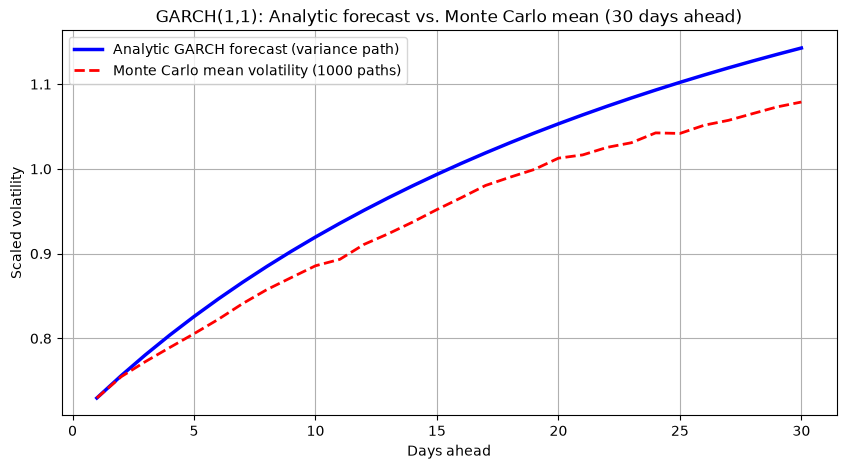

In [10]:
# 5. Sanity check: analytical GARCH forecast (closed-form mean variance path)
# `forecast()` computes the conditional variance iteratively using the same
# recursion as the Monte Carlo loop, but without random shocks — so its
# sqrt should track the *mean* of the simulated volatilities closely.
np.random.seed(42)  # keep RNG state consistent for reproducibility of the loop above

# `horizon` days out, starting from the in-sample end.
fc = fitted_model.forecast(horizon=horizon, reindex=False)
analytic_var = fc.variance.values[0]          # shape (horizon,)
analytic_vol = np.sqrt(analytic_var)

# Re-run the MC mean for a fair comparison (deterministic with the fixed seed).
mc_vol = np.zeros((horizon, num_sims))
for sim in range(num_sims):
    last_var = fitted_model.conditional_volatility.iloc[-1] ** 2
    last_res = fitted_model.resid.iloc[-1]
    for t in range(horizon):
        new_var = omega + alpha * (last_res ** 2) + beta * last_var
        new_vol = np.sqrt(new_var)
        z = np.random.normal(0, 1)
        mc_vol[t, sim] = new_vol
        last_var = new_var
        last_res = new_vol * z

mc_mean_vol = mc_vol.mean(axis=1)

print("Analytic (closed-form) forecast volatility:")
print(pd.Series(analytic_vol, index=range(1, horizon + 1)))
print("\nMonte Carlo mean volatility:")
print(pd.Series(mc_mean_vol, index=range(1, horizon + 1)))

max_abs_diff = np.abs(analytic_vol - mc_mean_vol).max()
rel_diff = max_abs_diff / analytic_vol.max()
print(f"\nMax |analytic - MC mean| = {max_abs_diff:.6f}  "
      f"(rel. to max analytic vol: {100 * rel_diff:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, horizon + 1), analytic_vol, color='blue',
        linewidth=2.5, label='Analytic GARCH forecast (variance path)')
ax.plot(np.arange(1, horizon + 1), mc_mean_vol, color='red', linewidth=2,
        linestyle='--', label='Monte Carlo mean volatility (1000 paths)')
ax.set_title(f'GARCH(1,1): Analytic forecast vs. Monte Carlo mean ({horizon} days ahead)')
ax.set_xlabel('Days ahead')
ax.set_ylabel('Scaled volatility')
ax.legend()
ax.grid(True)
plt.show()

In [1]:
import pandas as pd
import matplotlib as plt

data = pd.read_csv("/home/ttran/code/trading_data_platform/data/train.csv")
data.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Temp vs kWh
ax1.scatter(data['temp_avg_c'], data['kwh'], color='blue', alpha=0.5)
ax1.set_xlabel('Avg Temp (C)')
ax1.set_ylabel('kWh')
ax1.set_title('Avg Temperature vs kWh')
ax1.grid(True)

# Plot 2: Humidity vs kWh
ax2.scatter(data['humidity_pct'], data['kwh'], color='green', alpha=0.5)
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('kWh')
ax2.set_title('Humidity vs kWh')
ax2.grid(True)

plt.tight_layout()

plt.show()

AttributeError: module 'matplotlib' has no attribute 'subplots'

# Conductor Script

## Test Online

In [29]:
import requests
res = requests.post("http://localhost:4096/session", json={"title": "test"})
print("Status Code:", res.status_code)
print("Response JSON:", res.json())

Status Code: 200
Response JSON: {'id': 'ses_f16b1517dffeDe2FEA4OJU7Tf2', 'slug': 'quick-otter', 'projectID': 'global', 'directory': '/home/ttran', 'path': 'home/ttran', 'cost': 0, 'tokens': {'input': 0, 'output': 0, 'reasoning': 0, 'cache': {'read': 0, 'write': 0}}, 'title': 'test', 'version': '1.18.33', 'time': {'created': 1790620642947, 'updated': 1790620642947}}


## Update model list

In [ ]:
I want to get the model list in docker exec -it ollama ollama ls and write to /home/ttran/.config/opencode/opencode.jsonc. Follow existing configuration structure in opencode.jsonc.

In [37]:
import os
import requests
import re

OPENCODE_URL = "http://localhost:4096"
PROJECT_DIR = os.getcwd()

def create_session(title: str) -> str:
    """Create a new OpenCode session."""
    resp = requests.post(f"{OPENCODE_URL}/session", json={"title": title, "directory": PROJECT_DIR})
    resp.raise_for_status()
    payload = resp.json()
    return payload["id"] if "id" in payload else payload["data"]["id"]

def run_agent_task(session_id: str, agent_name: str, prompt: str) -> str:
    """Send a task to a specific sub-agent within a session and return its output text."""
    print(f"\n🚀 Launching [@{agent_name}]...")
    
    payload = {
        "agent": agent_name,
        "parts": [{"type": "text", "text": prompt}]
    }
    
    resp = requests.post(
        f"{OPENCODE_URL}/session/{session_id}/message", 
        json=payload,
        timeout=300
    )
    
    if not resp.ok:
        print(f"\n❌ OpenCode Error ({resp.status_code}):")
        try:
            print("Response details:", resp.json())
        except Exception:
            print("Response text:", resp.text)
        resp.raise_for_status()

    # Extract text from the OpenCode response payload
    data = resp.json()
    output_text = ""
    
    # Parse parts array from response
    parts = data.get("parts", []) or data.get("data", {}).get("parts", [])
    for part in parts:
        if part.get("type") == "text":
            output_text += part.get("text", "") + "\n"
            
    print(f"✅ Agent [@{agent_name}] completed phase.")
    return output_text.strip()

def extract_and_save_code(agent_output: str, default_filename: str = "hello.py"):
    """Parses markdown code blocks from LLM output and writes them to disk if missing."""
    if os.path.exists(default_filename):
        print(f"📁 Verified: {default_filename} exists on disk!")
        return

    # Look for python code blocks in LLM output
    pattern = r"```python\n(.*?)```"
    matches = re.findall(pattern, agent_output, re.DOTALL)
    
    if matches:
        code_content = matches[0].strip()
        with open(default_filename, "w") as f:
            f.write(code_content)
        print(f"⚠️ Agent didn't use native tools, but extracted and saved code to '{default_filename}' successfully.")
    else:
        print(f"❌ Could not find code or file for {default_filename}.")

def run_conductor(user_feature: str):
    """Main conductor script using a single session across all phases."""
    if not user_feature.strip():
        print("Please provide a valid feature description.")
        return

    os.makedirs(".context", exist_ok=True)
    print(f"--- Starting Conductor for: {user_feature} ---")

    # Use ONE session so agents share workspace state
    session_id = create_session(f"Workflow: {user_feature[:30]}")
    print(f"Session ID: {session_id}")

    # PHASE 1: Planning
    plan_output = run_agent_task(
        session_id, 
        "planner", 
        f"Create a step-by-step implementation plan for: {user_feature}. Save your plan to .context/PLAN.md."
    )
    print("\n--- PLANNER OUTPUT ---")
    print(plan_output)

    # PHASE 2: Development
    dev_output = run_agent_task(
        session_id, 
        "developer", 
        "Read .context/PLAN.md. Implement the Python code and write it directly to a file named hello.py."
    )
    print("\n--- DEVELOPER OUTPUT ---")
    print(dev_output)

    # Ensure file exists on disk
    extract_and_save_code(dev_output, "hello.py")

    # PHASE 3: Review & Validation
    review_output = run_agent_task(
        session_id, 
        "reviewer", 
        "Review `hello.py` and .context/PLAN.md. Save your findings to .context/REVIEW.md."
    )
    print("\n--- REVIEWER OUTPUT ---")
    print(review_output)

    # Check generated files
    if os.path.exists("hello.py"):
        with open("hello.py", "r") as f:
            print("\n--- Generated hello.py ---")
            print(f.read())

# --- Execute ---
task = "Make a code that says \"Hello world\" using 3 different methods in Python"
run_conductor(task)

--- Starting Conductor for: Make a code that says "Hello world" using 3 different methods in Python ---
Session ID: ses_f16719b95ffem6Yk6wh0YnSbfG

🚀 Launching [@planner]...
✅ Agent [@planner] completed phase.

--- PLANNER OUTPUT ---
I have created the implementation plan and saved it to `.context/PLAN.md`.

The plan consists of the following steps:
1.  **Define the Three Methods**:
    *   **Method 1: Direct Print**: Simple `print()` statement.
    *   **Method 2: Functional Approach**: A function `say_hello()`.
    *   **Method 3: Object-Oriented Approach**: A `Greeter` class with a `greet()` method.
2.  **Create the Python Script**: Implement all three methods in a file named `hello_world_methods.py` and execute them within an `if __name__ == "__main__":` block.
3.  **Verification**: Run the script and verify that "Hello world" is printed three times.

🚀 Launching [@developer]...
✅ Agent [@developer] completed phase.

--- DEVELOPER OUTPUT ---
I have implemented the Python code in `h